<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/Python_vs_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. ENABLING R MAGIC IN GOOGLE COLAB ---
To run R code inside Colab Python cells, use the %load_ext rpy2.ipython extension.



/tmp/ipykernel_524/1584181841.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


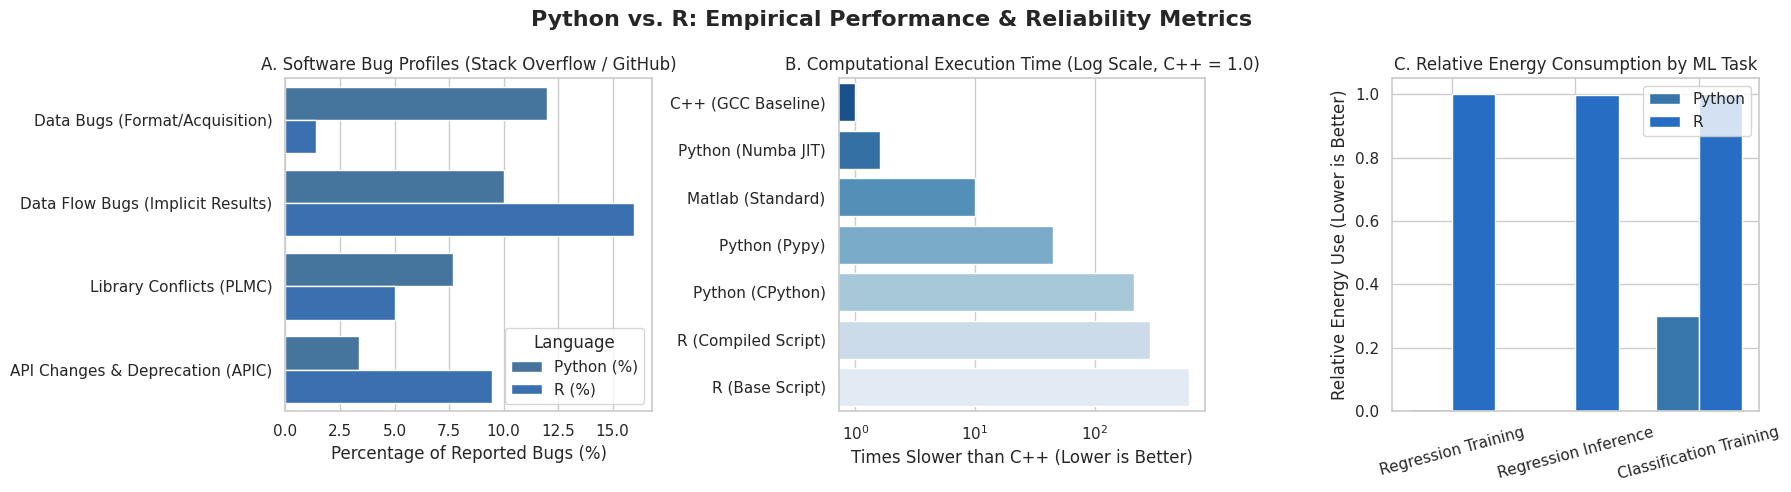


--- 4. SYNTACTIC & DOMAIN RECOMMENDATIONS ---
      Domain / Task      Recommended Tool                                  Key Source Finding
  Linear Regression       R stats package    More reliable, accurate, and flexible estimation
      ANOVA Testing   Python scikit-learn         Produces the most accurate ANOVA estimation
Classification (ML)   Python scikit-learn     Up to 84% more energy-efficient during training
 Data Visualization             R ggplot2    Declarative grammar of graphics & layered syntax
 Data Preprocessing Python Pandas / NumPy Explicit intermediate objects reduce Data Flow bugs
 Speed Optimization    Python + Numba JIT  Accelerates Python execution to 1.57x-1.62x of C++


In [4]:
# ==============================================================================
# GOOGLE COLAB: PYTHON VS R COMPARATIVE ANALYSIS & INTEROPERABILITY
# ==============================================================================
# This notebook visualises key empirical differences between Python and R
# based on published benchmarks and demonstrates running R directly inside Colab.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# ------------------------------------------------------------------------------
# 1. GOOGLE COLAB INTEROPERABILITY: RUNNING R IN PYTHON COLAB CELL
# ------------------------------------------------------------------------------
print("--- 1. ENABLING R MAGIC IN GOOGLE COLAB ---")

# In Google Colab, execute the magic command below to enable inline R execution:
# %load_ext rpy2.ipython

# Once loaded, you can write R code in any notebook cell starting with %%R:
r_example_code = """
%%R
# R Cell Example in Colab:
library(ggplot2)
data(mtcars)
cat("Running R inside Google Colab via rpy2!\n")
cat("Mean MPG:", mean(mtcars$mpg), "\n")
"""
print("To run R code inside Colab Python cells, use the %load_ext rpy2.ipython extension.\n")


# ------------------------------------------------------------------------------
# 2. DATASET DEFINITIONS (BENCHMARK DATA FROM LITERATURE)
# ------------------------------------------------------------------------------

# Benchmark 1: Energy Efficiency Comparison (arXiv Study)
# R is more energy-efficient for Regression; Python dominates Classification.
df_energy = pd.DataFrame(
    {
        "Task Category": [
            "Regression (Gaussian)",
            "Regression (Neural Net)",
            "Classification (Overall)",
            "Classification (LogReg)",
        ],
        "Python Energy Efficiency": [
            "Baseline",
            "Baseline",
            "65.5% to 84.2% More Efficient",
            "Up to 98.5% More Efficient",
        ],
        "R Energy Efficiency": [
            "99.16% More Efficient",
            "98.2% More Efficient",
            "Baseline",
            "Baseline",
        ],
        "Winner": ["R", "R", "Python", "Python"],
    }
)

# Benchmark 2: Bug Taxonomies & Causes (Stack Overflow / GitHub Study)
df_bugs = pd.DataFrame(
    {
        "Metric / Bug Category": [
            "Data Bugs (Format/Acquisition)",
            "Data Flow Bugs (Implicit Results)",
            "Library Conflicts (PLMC)",
            "API Changes & Deprecation (APIC)",
        ],
        "Python (%)": [12.0, 10.0, 7.69, 3.39],
        "R (%)": [1.4, 16.0, 5.01, 9.48],
    }
)

# Benchmark 3: Numerical Execution Speed relative to C++ (NBER Benchmark)
# (1.0 = C++ Baseline execution time)
df_speed = pd.DataFrame(
    {
        "Language / Runtime": [
            "C++ (GCC Baseline)",
            "Python (Numba JIT)",
            "Matlab (Standard)",
            "Python (Pypy)",
            "Python (CPython)",
            "R (Compiled Script)",
            "R (Base Script)",
        ],
        "Relative Run Time (x slower than C++)": [
            1.0,
            1.6,
            9.9,
            44.5,
            212.6,
            293.2,
            611.3,
        ],
    }
)

# ------------------------------------------------------------------------------
# 3. CREATING COMPARATIVE VISUALIZATION DASHBOARD
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Python vs. R: Empirical Performance & Reliability Metrics",
    fontsize=16,
    fontweight="bold",
)

# Plot A: Bug Taxonomy Prevalence
df_bugs_melted = df_bugs.melt(
    id_vars="Metric / Bug Category", var_name="Language", value_name="Prevalence (%)"
)

# Define custom colors
custom_palette_colors = {"Python (%)": "#3776AB", "R (%)": "#276DC3"}
# Get the order of hue categories from the melted DataFrame
hue_order = df_bugs_melted['Language'].unique()
# Create a list of colors in that order
palette_list = [custom_palette_colors[lang] for lang in hue_order]

sns.barplot(
    data=df_bugs_melted,
    x="Prevalence (%)",
    y="Metric / Bug Category",
    hue="Language",
    palette=palette_list,
    hue_order=hue_order,
    ax=axes[0],
)
axes[0].set_title("A. Software Bug Profiles (Stack Overflow / GitHub)")
axes[0].set_xlabel("Percentage of Reported Bugs (%)")
axes[0].set_ylabel("")

# Plot B: Execution Speed (Log Scale)
sns.barplot(
    data=df_speed,
    x="Relative Run Time (x slower than C++)",
    y="Language / Runtime",
    palette="Blues_r",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("B. Computational Execution Time (Log Scale, C++ = 1.0)")
axes[1].set_xlabel("Times Slower than C++ (Lower is Better)")
axes[1].set_ylabel("")

# Plot C: ML Energy Consumption Summary
categories = ["Regression Training", "Regression Inference", "Classification Training"]
py_energy = [0.0084, 0.002, 0.3] # Indexed relative values
r_energy = [1.0, 0.998, 1.0]

x = np.arange(len(categories))
width = 0.35

axes[2].bar(x - width / 2, py_energy, width, label="Python", color="#3776AB")
axes[2].bar(x + width / 2, r_energy, width, label="R", color="#276DC3")
axes[2].set_title("C. Relative Energy Consumption by ML Task")
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories, rotation=15)
axes[2].set_ylabel("Relative Energy Use (Lower is Better)")
axes[2].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. SUMMARY RECOMMENDATIONS TABLE
# ------------------------------------------------------------------------------
print("\n--- 4. SYNTACTIC & DOMAIN RECOMMENDATIONS ---")
summary_df = pd.DataFrame(
    {
        "Domain / Task": [
            "Linear Regression",
            "ANOVA Testing",
            "Classification (ML)",
            "Data Visualization",
            "Data Preprocessing",
            "Speed Optimization",
        ],
        "Recommended Tool": [
            "R stats package",
            "Python scikit-learn",
            "Python scikit-learn",
            "R ggplot2",
            "Python Pandas / NumPy",
            "Python + Numba JIT",
        ],
        "Key Source Finding": [
            "More reliable, accurate, and flexible estimation",
            "Produces the most accurate ANOVA estimation",
            "Up to 84% more energy-efficient during training",
            "Declarative grammar of graphics & layered syntax",
            "Explicit intermediate objects reduce Data Flow bugs",
            "Accelerates Python execution to 1.57x-1.62x of C++",
        ],
    }
)

print(summary_df.to_string(index=False))